<a href="https://colab.research.google.com/github/yamasakitetuya/dive_into_dl/blob/main/Multi_layer_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install d2l==1.0.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.1/34.1 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.3/98.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfull

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
class MLPScratch(d2l.Classifier):
  def __init__(self, num_inputs, num_outputs, num_hiddens, lr, sigma=0.01):
    super().__init__()
    self.save_hyperparameters()
    self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
    self.b1 = nn.Parameter(torch.zeros(num_hiddens))
    self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
    self.b2 = nn.Parameter(torch.zeros(num_outputs))




In [3]:
def relu(X):
  a = torch.zeros_like(X)
  return torch.max(X,a)

@d2l.add_to_class(MLPScratch)
def forward(self, X):
  X = X.reshape((-1, self.num_inputs))
  H = relu(torch.matmul(X, self.W1) + self.b1)
  return torch.matmul(H, self.W2) + self.b2



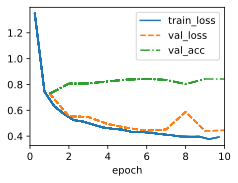

In [5]:
model = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256, lr=0.1)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

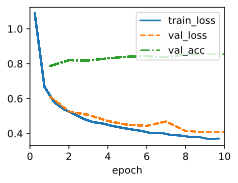

In [6]:
class MLP(d2l.Classifier):
  def __init__(self, num_outputs, num_hiddens, lr):
    super().__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(num_hiddens),
        nn.ReLU(),
        nn.LazyLinear(num_outputs)
    )


model = MLP(num_outputs=10, num_hiddens=256, lr=0.1)
trainer.fit(model, data)

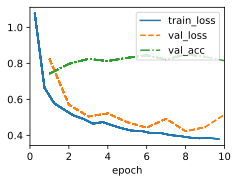

In [7]:
model = MLP(num_outputs=10, num_hiddens=128, lr=0.1)
trainer.fit(model, data)

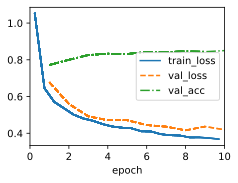

In [8]:
model = MLP(num_outputs=10, num_hiddens = 512, lr = 0.1)
trainer.fit(model, data)

In [9]:
class MLP_2hl(d2l.Classifier):
  def __init__(self, num_outputs, num_hiddens, lr):
    super().__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.LazyLinear(num_hiddens),
        nn.ReLU(),
        nn.LazyLinear(num_hiddens),
        nn.ReLU(),
        nn.LazyLinear(num_outputs)
    )

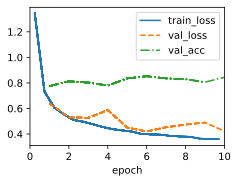

In [10]:
model = MLP_2hl(num_outputs=10, num_hiddens=128, lr=0.1)
trainer.fit(model, data)